## Feature extraction

**Objective:** Build and validate feature extraction on a single pilot subject before 
scaling to the full cohort. Covers all feature families: band power, PLI, coherence, PLV, 
and Kuramoto. Built incrementally across sessions; each family is validated on the pilot 
subject before the next is added.

**Inputs:**
- Pilot subject's preprocessed epochs (restEC, heog_off), from `data/derivatives/<subject_id>/`
- QC dict from `run_autoreject` (n_epochs, autoreject_extreme, consensus/n_interpolate)
- Bands matched to Chang et al. (2025): delta 2-4 Hz, theta 4-8 Hz, alpha 8-13 Hz, 
  beta 13-30 Hz, gamma 30-45 Hz 

**Assumptions (from modelling_decisions.md):**
- Mean aggregation across retained epochs, per feature, per subject 
- Raw, untransformed feature output for power; log-transform is modelling-stage only 
- PLI is the primary connectivity metric; coherence and PLV are secondary 
- QC dict passed in as-is, not re-derived 
- Failed subjects get a flagged row (NaN features, reason column), never a dropped None
- Naming: `{channel}_{band}_power`, `{channel1}_{channel2}_{band}_{metric}` 
- Full feature bank computed once; primary arm's curated pool is a column subset applied 
  at modelling time, not a separate extraction path

**Progress:**
- [X] Band power
- [X] PLI
- [X] Coherence, PLV
- [X] Kuramoto

In [1]:
# imports and setup
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import *
from mne_connectivity import spectral_connectivity_epochs
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# Load pilot subject (same subject from '02_preprocessing_pilot.ipynb') 

data_dir = find_repo_root() / "data"

subject_id = 'sub-87999321'
condition = 'restEC'
variant = 'heog_off'

epochs_path = data_dir / f'derivatives_{variant}' / subject_id / f'{subject_id}_{condition}-epo.fif'
epochs = mne.read_epochs(epochs_path)

print(epochs)

Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>


In [3]:
# Load QC 
qc_log = pd.read_csv(data_dir / 'batch_results_log_full_cohort.csv')
print(qc_log.columns.tolist())
print(qc_log.head())

['subject_id', 'condition', 'heog_variant', 'status', 'n_epochs_before', 'n_epochs_after', 'output_path', 'autoreject_consensus', 'autoreject_n_interpolate', 'autoreject_extreme', 'heog_n_candidates', 'heog_n_valid', 'heog_correction_applied', 'error']
     subject_id condition heog_variant status  n_epochs_before  \
0  sub-87999321    restEC     heog_off     ok             24.0   
1  sub-87999321    restEO     heog_off     ok             24.0   
2  sub-87999321    restEC      heog_on     ok             24.0   
3  sub-87999321    restEO      heog_on     ok             24.0   
4  sub-88049537    restEC     heog_off     ok             24.0   

   n_epochs_after                                        output_path  \
0            23.0  /Users/romyweinstock/eeg-rtms-response-predict...   
1            22.0  /Users/romyweinstock/eeg-rtms-response-predict...   
2            23.0  /Users/romyweinstock/eeg-rtms-response-predict...   
3            22.0  /Users/romyweinstock/eeg-rtms-response-pred

In [4]:
# Filter the combined QC log down to this subject's row for the given condition and HEOG variant. 
qc_row = qc_log[
    (qc_log['subject_id'] == subject_id) &
    (qc_log['condition'] == condition) &
    (qc_log['heog_variant'] == variant)
]

# Fail loudly if the filter doesn't return exactly one row
assert len(qc_row) == 1, f"expected exactly 1 QC row, got {len(qc_row)}"

# Convert to a plain dict so it can be passed into extract_subject_features
qc_info = qc_row.iloc[0].to_dict()

print(qc_info)

{'subject_id': 'sub-87999321', 'condition': 'restEC', 'heog_variant': 'heog_off', 'status': 'ok', 'n_epochs_before': 24.0, 'n_epochs_after': 23.0, 'output_path': '/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif', 'autoreject_consensus': 0.2, 'autoreject_n_interpolate': 4.0, 'autoreject_extreme': False, 'heog_n_candidates': 4.0, 'heog_n_valid': 0.0, 'heog_correction_applied': False, 'error': nan}


In [5]:
# Compute band power
spectrum = epochs.compute_psd(method='welch')
print(spectrum)

# Get frequencies and power values
freqs = spectrum.freqs
power_data_array = spectrum.get_data()

# Confirm channel alignment: epochs.ch_names includes non-EEG channels
# (Erbs, Mass, Status, VEOG, HEOG) - 31 total - while spectrum only computed
# PSD for the 26 EEG channels. Use spectrum.ch_names, not epochs.ch_names,
# whenever pairing channel names with power values.
print(len(epochs.ch_names), len(spectrum.ch_names))
print(power_data_array.shape)  # (23 epochs, 26 channels, 1025 freqs)

# Band boundaries,  half-open intervals (lower inclusive, upper exclusive)
# to avoid double-counting a bin that lands exactly on a boundary
bands = {
    "delta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

# For each band: mask the relevant frequency bins, sum across them,
# then mean across epochs -> one value per channel
band_power = {}

for band_name, (low, high) in bands.items():
    mask = (freqs >= low) & (freqs < high)
    band_slice = power_data_array[:, :, mask]      # (23, 26, n_freqs_in_band)
    band_sum = np.sum(band_slice, axis=2)            # (23, 26)
    band_mean = np.mean(band_sum, axis=0) * 1e12  # V^2/Hz -> uV^2/Hz

    for channel, value in zip(spectrum.ch_names, band_mean):
        band_power[f"{channel}_{band_name}_power"] = value
# Confirm no NaNs slipped through - a NaN here would silently propagate into
# every downstream step (dataframe row, modelling matrix) without erroring
assert not any(np.isnan(v) for v in band_power.values()), "NaN found in band_power"

print(len(band_power))              # expect 130 (26 channels x 5 bands)
print(list(band_power.items())[:5]) # spot-check a few entries

# Pull out the alpha values specifically for O1, O2, Pz (posterior) and Fp1, Fp2 (frontal), and compare them 
posterior = ['O1', 'O2', 'Pz']
frontal = ['Fp1', 'Fp2']

for ch in posterior + frontal:
    print(ch, band_power[f"{ch}_alpha_power"])

Effective window size : 4.096 (s)
<Power Spectrum (from Epochs, welch method) | 23 epochs × 26 channels × 1025 freqs, 0.0-250.0 Hz>
31 26
(23, 26, 1025)
130
[('Fp1_delta_power', np.float64(35.41828852559409)), ('Fp2_delta_power', np.float64(34.988788065319014)), ('F7_delta_power', np.float64(28.24902379025797)), ('F3_delta_power', np.float64(33.13220605971701)), ('Fz_delta_power', np.float64(40.28291528903178))]
O1 208.11167873107232
O2 187.32865650971894
Pz 170.79886995121103
Fp1 110.49959001661445
Fp2 113.23930917617187


In [6]:
## Check pilot subject using built functions from 'fratures.py'

# Import funcitons 
from src.features import (load_subject_epochs, get_subject_qc, compute_band_power)

# Define needed parameters
data_dir = find_repo_root() / "data"
qc_log = pd.read_csv(data_dir / 'batch_results_log_full_cohort.csv')
bands = {
    "delta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

epochs = load_subject_epochs(subject_id = 'sub-87999321',condition = 'restEC', variant = 'heog_off', data_dir = data_dir)
qc_info = get_subject_qc(subject_id = 'sub-87999321',condition = 'restEC', variant = 'heog_off', qc_log = qc_log)
band_power = compute_band_power(epochs = epochs, bands = bands)

#checks
# Column count check
print(len(band_power))  # expect 130

# Posterior vs frontal alpha - should match the notebook version
posterior = ['O1', 'O2', 'Pz']
frontal = ['Fp1', 'Fp2']

for ch in posterior + frontal:
    print(ch, band_power[f"{ch}_alpha_power"])

# Exact-match spot check against the validated notebook value
print(band_power['Fp1_delta_power'])  # expect ~35.418288525594...

Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
130
O1 208.11167873107232
O2 187.32865650971894
Pz 170.79886995121103
Fp1 110.49959001661445
Fp2 113.23930917617187
35.41828852559409


In [7]:
## Check orchestrator function (successful run)
from src.features import (extract_subject_features)

results = extract_subject_features(
    subject_id = 'sub-87999321',
    condition = 'restEC',
     variant = 'heog_off', 
     data_dir = data_dir,
     qc_log = qc_log,
     bands = bands
     )
results 

Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI
    computing cross-spectral density for epoch 1
    computing cross-spectral de

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spect

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]


{'subject_id': 'sub-87999321',
 'condition': 'restEC',
 'variant': 'heog_off',
 'reason': 'ok',
 'heog_variant': 'heog_off',
 'preprocessing_status': 'ok',
 'n_epochs_before': 24.0,
 'n_epochs_after': 23.0,
 'output_path': '/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif',
 'autoreject_consensus': 0.2,
 'autoreject_n_interpolate': 4.0,
 'autoreject_extreme': False,
 'heog_n_candidates': 4.0,
 'heog_n_valid': 0.0,
 'heog_correction_applied': False,
 'preprocessing_error': nan,
 'Fp1_delta_power': np.float64(35.41828852559409),
 'Fp2_delta_power': np.float64(34.988788065319014),
 'F7_delta_power': np.float64(28.24902379025797),
 'F3_delta_power': np.float64(33.13220605971701),
 'Fz_delta_power': np.float64(40.28291528903178),
 'F4_delta_power': np.float64(31.59585452670465),
 'F8_delta_power': np.float64(16.74755844345798),
 'FC3_delta_power': np.float64(32.14540771782294),
 'FCz_delta_power': np.float64(45.678578112546

In [8]:
## Check orchestrator function (failed run - madeup subject)

results = extract_subject_features(
    subject_id = 'sub-87999328',
    condition = 'restEC',
     variant = 'heog_off', 
     data_dir = data_dir,
     qc_log = qc_log,
     bands = bands
     )
results

{'subject_id': 'sub-87999328',
 'condition': 'restEC',
 'variant': 'heog_off',
 'reason': 'File does not exist: "/Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999328/sub-87999328_restEC-epo.fif"'}

In [9]:
# Build one real success row and one real failure row, then check that
# concatenating them into a dataframe produces clean NaN-filling for the
# columns the failure row never computed

success_row = extract_subject_features(
    subject_id='sub-87999321', condition='restEC', variant='heog_off',
    data_dir=data_dir, qc_log=qc_log, bands=bands
)

failure_row = extract_subject_features(
    subject_id='sub-87999328', condition='restEC', variant='heog_off',
    data_dir=data_dir, qc_log=qc_log, bands=bands
)

test_df = pd.DataFrame([success_row, failure_row])

print(test_df.shape)
print(test_df[['subject_id', 'condition', 'variant', 'reason']])

# Check a QC column and a feature column specifically - both should be
# NaN for the failure row, real values for the success row
print(test_df[['n_epochs_after', 'Fp1_delta_power']])

Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-87999321/sub-87999321_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI
    computing cross-spectral density for epoch 1
    computing cross-spectral de

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral 

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
(2, 5031)
     subject_id condition   variant  \
0  sub-87999321    restEC  heog_off   
1  sub-87999328    restEC  heog_off   

                                              reason  
0                                                 ok  
1  File does not exist: "/Users/romyweinstock/eeg...  
   n_epochs_after  Fp1_delta_power
0            23.0        35.418289
1             NaN              NaN


In [10]:
#validate how many Nas exist across the 2-row test dataframe.
print(test_df.isna().sum())

subject_id             0
condition              0
variant                0
reason                 0
heog_variant           1
                      ..
alpha_metastability    1
beta_order             1
beta_metastability     1
gamma_order            1
gamma_metastability    1
Length: 5031, dtype: int64


## Interpretation - band power

Band power extraction validated on the pilot subject (sub-87999321, restEC, heog_off).

**Checklist results (Decision 5):**
- Column count: 130 (26 channels x 5 bands), exact match
- No NaNs: confirmed via assert, both in the notebook derivation and the
  refactored `compute_band_power` function
- Units: raw PSD output is in V^2/Hz (MNE's native unit), not uV^2/Hz as
  reported in the literature. Converted via *1e12. Caught before it reached
  any stored feature - the unconverted value would have been off by 12
  orders of magnitude.
- Physiological plausibility: posterior alpha (O1, O2, Pz: ~171-208 uV^2/Hz)
  visibly exceeds frontal alpha (Fp1, Fp2: ~110-113 uV^2/Hz), consistent
  with expected resting-EEG topography.

**Decisions made this session (to be added to modelling_decisions.md):**
- PSD method: Welch, not MNE's multitaper default. Chang et al. (2025)
  states "FFT" without specifying segmentation; Roelofs et al. (2021)'s
  similarly-described method is Welch by construction, and Stolz et al.
  (2023) - a separate TDBRAIN-based rTMS study - names Welch explicitly.
  Welch's default window size (4.096s) was accepted as MNE's default, not
  independently checked against segment-length choices in the cited papers.

**Bugs caught during build (not shipped):**
- `epochs.ch_names` (31, includes EOG/Erbs/Mass/Status) vs
  `spectrum.ch_names` (26, EEG only) - using the former would have
  silently mislabeled every power value.
- Band mask boundaries initially double-counted bins landing exactly on a
  boundary (`<=` on both sides); fixed to half-open intervals.
- QC log's own `status`/`error` columns collided with the orchestrator's
  `reason` field on merge; renamed to `preprocessing_status` /
  `preprocessing_error` to disambiguate pipeline stage.

**Refactor validation:** `compute_band_power` in `src/features.py`
reproduces the notebook-derived values exactly (spot-checked
Fp1_delta_power: 35.41828852559409, identical to 15 decimal places).

**Orchestrator (`extract_subject_features`):** tested against one real
success case and one deliberate failure case (nonexistent subject ID).
Confirmed `pd.DataFrame([...])` correctly NaN-fills missing QC/feature
columns for failed rows with no custom handling needed.


**Progress:**
- [x] Band power
- [ ] PLI
- [ ] Coherence, PLV
- [ ] Kuramoto

## PLI connectivity extraction

**Objective**: Build and validate PLI (phase lag index) as the primary connectivity feature, on the pilot subject, following the same build-then-validate-then-refactor discipline used for band power.

**Inputs**: Same pilot subject epochs (sub-87999321, restEC, heog_off) already loaded above.

Scope:

- PLI computed across all 5 bands (delta, theta, alpha, beta, gamma). Alpha-band PLI has direct stability evidence (Dominicus et al., 2025); the other bands are computed for completeness and secondary-arm availability, without that same stability grounding, and will be noted as such when the primary arm's curated pool is finalized.
- Upper-triangle channel pairs only, no diagonal (325 pairs from 26 channels), avoiding the perfect collinearity a full symmetric matrix would introduce.
- Naming convention: {channel1}_{channel2}_{band}_pli

In [11]:
# Build upper-triangle channel-pair indices
picks = mne.pick_types(epochs.info, eeg=True) # channel indices
ch_names = [epochs.ch_names[i] for i in picks] # channel names, same order

pairs = list(combinations(range(len(ch_names)), 2))
seeds = [i[0] for i in pairs]
targets = [j[1] for j in pairs]

# Call spectral_connectivity_epochs
indices = (seeds, targets)

fmin = tuple(low for (low, high) in bands.values())
fmax = tuple(high for (low, high) in bands.values())

con = spectral_connectivity_epochs(
    data=epochs,
    method='pli',
    indices=indices,
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    sfreq=epochs.info['sfreq'],
)
#validate shape
print(con.get_data().shape)

Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectra

/var/folders/sj/n3g071kn3k5d875m963jywkr0000gn/T/ipykernel_11154/3331225965.py:15: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
(325, 5)


In [12]:
# Extracting values into the flat dict
con_data = con.get_data()
pli_results = {}

for p, (i, j) in enumerate(pairs):
    for b, band_name in enumerate(bands):
        pli_results[f"{ch_names[i]}_{ch_names[j]}_{band_name}_pli"] = con_data[p, b]

print(len(pli_results))
print(list(pli_results.items())[:3])

1625
[('Fp1_Fp2_delta_pli', np.float64(0.16205533596837945)), ('Fp1_Fp2_theta_pli', np.float64(0.11801242236024846)), ('Fp1_Fp2_alpha_pli', np.float64(0.137123745819398))]


In [13]:
# Validation checks
assert len(pli_results) == 325 * 5, f"expected 1625, got {len(pli_results)}"
assert all(0 <= v <= 1 for v in pli_results.values()), "PLI value outside [0,1] found"
assert not any(np.isnan(v) for v in pli_results.values()), "NaN found in pli_results"

print("All checks passed")

All checks passed


In [14]:
## Check PLI function (refactored, from src/features.py)
from src.features import compute_pli

pli_results_refactored = compute_pli(epochs=epochs, bands=bands)

# Column count check
print(len(pli_results_refactored))  # expect 1625

# Exact-match spot check against the notebook-derived values
print(pli_results_refactored['Fp1_Fp2_delta_pli'])   # expect 0.16205533596837945
print(pli_results_refactored['Fp1_Fp2_theta_pli'])   # expect 0.11801242236024846
print(pli_results_refactored['Fp1_Fp2_alpha_pli'])   # expect 0.137123745819398

# Full equality check across every key, not just three spot-checks
mismatches = {
    k: (pli_results[k], pli_results_refactored[k])
    for k in pli_results
    if pli_results[k] != pli_results_refactored[k]
}
print(f"Mismatched keys: {len(mismatches)}")

Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectra

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
1625
0.16205533596837945
0.11801242236024846
0.137123745819398
Mismatched keys: 0


In [15]:
from src.features import extract_subject_features

# Small batch of subjects for the PLI batch check (not the full cohort list)
derivatives_heog_off_path = data_dir / "derivatives_heog_off"
batch_paths = list(derivatives_heog_off_path.rglob("sub-*_restEC-epo.fif"))[:6]
batch_subject_ids = [p.stem.split("_")[0] for p in batch_paths]
print(batch_subject_ids)

batch_results = []
for subject_id in batch_subject_ids:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    batch_results.append(result)

batch_df = pd.DataFrame(batch_results)
print(batch_df.shape)  # expect (6, 146 + 1625 = 1771)
print((batch_df['reason'] == 'ok').sum(), "/ 6 succeeded")

['sub-88045809', 'sub-88022765', 'sub-88023485', 'sub-88061061', 'sub-88021321', 'sub-88077569']
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88045809/sub-88045809_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will 

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral de

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88022765/sub-88022765_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Usi

...

    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88077569/sub-88077569_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    conne

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
(6, 5031)
6 / 6 succeeded


In [16]:
# Quick batch-level checks, mirroring what full-cohort QC will need
print(batch_df['reason'].tolist())  # confirm all say 'ok', not just count

pli_cols = [c for c in batch_df.columns if c.endswith('_pli')]
print(f"PLI columns: {len(pli_cols)}")  # expect 1625

pli_values = batch_df[pli_cols].values
print("Any NaNs:", pd.isna(pli_values).any())
print("Any out of [0,1]:", ((pli_values < 0) | (pli_values > 1)).any())

['ok', 'ok', 'ok', 'ok', 'ok', 'ok']
PLI columns: 1625
Any NaNs: False
Any out of [0,1]: False


## Interpretation - PLI connectivity

PLI extraction validated on the pilot subject (sub-87999321, restEC, heog_off)
and a 6-subject batch.

**Checklist results:**
- Column count: 1625 (325 upper-triangle channel pairs x 5 bands), exact match
- No NaNs, no out-of-range values: confirmed via assert, both in the notebook
  derivation and the refactored `compute_pli` function - PLI has a hard
  mathematical property (values in [0,1]) that band power doesn't, so this
  check was added on top of the NaN check used for band power.
- Batch check (6 subjects, varying epoch counts 21-24): 6/6 succeeded, all
  1625x6 values within [0,1], no NaNs.

**Decisions made this session (to be added to modelling_decisions.md):**
- Tool choice: `mne_connectivity.spectral_connectivity_epochs` (v0.8.1),
  not a manual Hilbert-transform build. A validated library implementation
  was judged lower-risk than re-deriving circular phase statistics from
  scratch.
- Pair structure: upper-triangle only (325 of 676 possible pairs), excluding
  the diagonal and reverse duplicates - a full matrix would introduce
  perfectly collinear duplicate columns into the feature matrix.
- Band scope: all 5 bands computed, matching band power's scope, per
  Decision 5's "compute the full feature bank once, curate at modelling
  time" pattern. Alpha-band PLI has direct stability evidence (Dominicus
  et al., 2025); the other 4 bands are computed for completeness and
  secondary-arm availability without that same grounding, to be flagged
  explicitly when the primary arm's curated pool is finalized.
- Epoch aggregation: handled internally by `spectral_connectivity_epochs`
  via cross-spectral density accumulated across epochs, not a literal
  per-epoch-PLI-then-mean loop.

**Refactor validation:** `compute_pli` in `src/features.py` reproduces all
1625 notebook-derived values exactly (full equality check across every key,
not just spot-checks: 0/1625 mismatches).

**Orchestrator (`extract_subject_features`):** updated to call `compute_pli`
alongside `compute_band_power`, merging both into the same flat result dict.
Batch-tested on 6 subjects (not the deliberate-failure case re-tested here,
since that was already covered for the orchestrator's NaN-fill behavior
during band power's validation).

**Progress:**
- [x] Band power
- [x] PLI
- [ ] Coherence, PLV
- [ ] Kuramoto

## Coherence and PLV connectivity

**Objective**: Build and validate coherence and PLV as the secondary connectivity metrics (per Decision 2), on the pilot subject, following the same build-then-validate-then-refactor discipline used for PLI. These serve as a comparison against PLI, testing how much of any connectivity signal survives PLI's volume-conduction correction.

**Inputs**: Same pilot subject epochs (sub-87999321, restEC, heog_off) already loaded above.

**Conceptual grounding**: Coherence uses both amplitude and phase (a normalized cross-spectral measure), making it vulnerable to volume conduction - two electrodes over the same underlying source show high coherence regardless of genuine functional connectivity. PLV is phase-only like PLI, but unlike PLI does not discard zero-lag phase relationships, so it retains the same volume-conduction vulnerability that PLI's design specifically corrects for. Comparing all three lets Decision 2's stated goal be tested directly: if PLI and coherence/PLV show similar patterns, that supports genuine connectivity; if coherence/PLV show a stronger effect PLI doesn't, that points to volume-conduction artifact in the uncorrected metrics.

Scope, matching PLI's: all 5 bands, upper-triangle channel pairs only (325 pairs), same naming convention extended with _coh/_plv suffixes.

In [17]:
# Test: can spectral_connectivity_epochs compute multiple methods in one call?
con_multi = spectral_connectivity_epochs(
    data=epochs,
    method=['pli', 'coh', 'plv'],
    indices=indices,
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    sfreq=epochs.info['sfreq'],
)

print(type(con_multi))
print(len(con_multi))
for c in con_multi:
    print(type(c), c.get_data().shape)

Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI, Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computi

/var/folders/sj/n3g071kn3k5d875m963jywkr0000gn/T/ipykernel_11154/29258612.py:2: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
<class 'list'>
3
<class 'mne_connectivity.base.SpectralConnectivity'> (325, 5)
<class 'mne_connectivity.base.SpectralConnectivity'> (325, 5)
<class 'mne_connectivity.base.SpectralConnectivity'> (325, 5)


In [18]:
# Confirm the order of con_multi matches the order passed to method=[...]
for c in con_multi:
    print(c.method)

pli
coh
plv


In [19]:
from src.features import compute_coherence_plv
coherence_plv_results_refactored = compute_coherence_plv(epochs=epochs, bands=bands)

print(len(coherence_plv_results_refactored))  # expect 3250

sample_keys = [k for k in coherence_plv_results_refactored if 'Fp1_Fp2_alpha' in k]
print(sample_keys)
for k in sample_keys:
    print(k, coherence_plv_results_refactored[k])

Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cr

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 14
    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
3250
['Fp1_Fp2_alpha_coh', 'Fp1_Fp2_alpha_plv']
Fp1_Fp2_alpha_coh 0.9471014156164781
Fp1_Fp2_alpha_plv 0.9930024626359374


In [20]:
from src.features import extract_subject_features

# Small batch of subjects for the coherence/PLV batch check
derivatives_heog_off_path = data_dir / "derivatives_heog_off"
batch_paths = list(derivatives_heog_off_path.rglob("sub-*_restEC-epo.fif"))[:6]
batch_subject_ids = [p.stem.split("_")[0] for p in batch_paths]
print(batch_subject_ids)

batch_results = []
for subject_id in batch_subject_ids:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    batch_results.append(result)

batch_df = pd.DataFrame(batch_results)
print(batch_df.shape)  # expect (6, 146 + 1625 + 3250 = 5021)
print(batch_df['reason'].tolist())

['sub-88045809', 'sub-88022765', 'sub-88023485', 'sub-88061061', 'sub-88021321', 'sub-88077569']
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88045809/sub-88045809_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will 

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral de

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88022765/sub-88022765_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS wind

...

    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88077569/sub-88077569_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    conne

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
(6, 5031)
['ok', 'ok', 'ok', 'ok', 'ok', 'ok']


In [21]:
# Range/NaN checks, extended to cover both new metrics:
coh_cols = [c for c in batch_df.columns if c.endswith('_coh')]
plv_cols = [c for c in batch_df.columns if c.endswith('_plv')]
print(f"Coherence columns: {len(coh_cols)}, PLV columns: {len(plv_cols)}")  # expect 1625 each

coh_plv_values = batch_df[coh_cols + plv_cols].values
print("Any NaNs:", pd.isna(coh_plv_values).any())
print("Any out of [0,1]:", ((coh_plv_values < 0) | (coh_plv_values > 1)).any())

Coherence columns: 1625, PLV columns: 1625
Any NaNs: False
Any out of [0,1]: False


In [22]:
# Manually derive coherence and PLV values, independent of compute_coherence_plv for comparison
con_multi_check = spectral_connectivity_epochs(
    data=epochs,
    method=['coh', 'plv'],
    indices=indices,
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    sfreq=epochs.info['sfreq'],
)

coherence_plv_results = {}
for con in con_multi_check:
    metric_name = con.method
    con_data = con.get_data()
    for p, (i, j) in enumerate(pairs):
        for b, band_name in enumerate(bands):
            key = f"{ch_names[i]}_{ch_names[j]}_{band_name}_{metric_name}"
            coherence_plv_results[key] = con_data[p, b]

print(len(coherence_plv_results))  # expect 3250

Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cr

/var/folders/sj/n3g071kn3k5d875m963jywkr0000gn/T/ipykernel_11154/196416160.py:2: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 23 events (all good), 0 – 4.998 s (baseline off), ~13.6 MiB, data loaded,
 '1': 23>, so metadata was not modified.
  con_multi_check = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
3250


In [23]:
# Full equality check: manually-derived coherence_plv_results vs. compute_coherence_plv's refactored output 
mismatches = {
    k: (coherence_plv_results[k], coherence_plv_results_refactored[k])
    for k in coherence_plv_results
    if coherence_plv_results[k] != coherence_plv_results_refactored[k]
}
print(f"Mismatched keys: {len(mismatches)} / {len(coherence_plv_results)}")

Mismatched keys: 0 / 3250


## Interpretation - coherence and PLV connectivity

Coherence and PLV extraction validated on the pilot subject (sub-87999321, restEC, heog_off) and a 6-subject batch.

**Checklist results:**
- Column count: 3250 (325 pairs x 5 bands x 2 metrics), exact match
- No NaNs, no out-of-range values: confirmed via assert, both bounded [0,1]
- Batch check (6 subjects, epoch counts 21-24): 6/6 succeeded, all 5021 columns present, coh/plv within [0,1], no NaNs

**Decisions made this session:**
- Single call (`method=['coh', 'plv']`) computes both metrics together, returning a list of `SpectralConnectivity` objects in the order passed - confirmed via `.method`, not assumed. PLI kept in its own function to avoid redundant computation.
- Same scope as PLI: all 5 bands, upper-triangle pairs only, same reasoning as documented there.

**Illustrative (not validation evidence):** Fp1-Fp2, alpha, pilot subject - coherence 0.947, PLV 0.993, vs. PLI 0.137. Concrete demonstration of Decision 2's rationale: coherence/PLV lack PLI's volume-conduction correction and show near-maximal connectivity between adjacent electrodes, likely shared-source contamination, while PLI suppresses it. Single-subject, single-pair - illustrative only.

**Orchestrator.** Updated to call `compute_coherence_plv` alongside `compute_band_power` and `compute_pli`. Batch-tested on 6 subjects: 6/6 succeeded, all values in [0,1], no NaNs.

**Progress:**
- [x] Band power
- [x] PLI
- [x] Coherence, PLV 
- [ ] Kuramoto

## Kuramoto: filter edge-effect diagnostic

**Objective.** Filtering short (~5s) epochs can distort the phase signal near the edges, especially for narrow, low-frequency bands.
Before building `compute_kuramoto`, check how bad this is empirically - delta (2-4 Hz) as the worst case, one higher band for comparison.

**Approach.** Filter one epoch, apply the Hilbert transform, compute R(t) across the full epoch. Compare order parameter and metastability
from (a) the full epoch vs. (b) a trimmed middle portion. Similar values -> edges aren't a problem. Different values -> trimming is needed going forward.

**Assumptions.** Uses `epochs.filter()` / `epochs.apply_hilbert()`, consistent with using validated MNE tooling elsewhere rather than manual `scipy` reimplementation.

In [24]:
# Kuramoto: filter edge-effect diagnostic
# Compares full-epoch vs. trimmed-epoch order parameter / metastability
# for delta (worst case: narrow, low frequency) vs. gamma (best case: wide, high frequency)

eeg_picks = mne.pick_types(epochs.info, eeg=True)
trim_frac = 0.2  # trim 20% off each side for the "trimmed" comparison

def kop_diagnostic(epochs, band_name, low, high, epoch_idx=0, trim_frac=0.2):
    epochs_filt = epochs.copy().filter(l_freq=low, h_freq=high, picks=eeg_picks, verbose=False)
    epochs_filt.apply_hilbert(picks=eeg_picks, envelope=False)

    analytic = epochs_filt.get_data(picks=eeg_picks)  # (n_epochs, n_channels, n_times), complex
    theta = np.angle(analytic)

    theta_epoch = theta[epoch_idx]  # (n_channels, n_times)
    R_t = np.abs(np.mean(np.exp(1j * theta_epoch), axis=0))  # (n_times,)

    n_times = R_t.shape[0]
    trim_n = int(n_times * trim_frac)
    R_t_trimmed = R_t[trim_n: n_times - trim_n]

    full_order, full_meta = R_t.mean(), R_t.std()
    trimmed_order, trimmed_meta = R_t_trimmed.mean(), R_t_trimmed.std()

    print(f"--- {band_name} ({low}-{high} Hz) ---")
    print(f"Full epoch:    order={full_order:.4f}, metastability={full_meta:.4f}")
    print(f"Trimmed epoch: order={trimmed_order:.4f}, metastability={trimmed_meta:.4f}")
    print(f"Order diff: {abs(full_order - trimmed_order):.4f}, Metastability diff: {abs(full_meta - trimmed_meta):.4f}")

    plt.figure(figsize=(8, 3))
    plt.plot(R_t, label="R(t)")
    plt.axvline(trim_n, color='red', linestyle='--', label='trim boundary')
    plt.axvline(n_times - trim_n, color='red', linestyle='--')
    plt.title(f"R(t) - {band_name}")
    plt.xlabel("timepoint")
    plt.ylabel("R(t)")
    plt.legend()
    plt.show()

    return R_t, R_t_trimmed

--- delta (2-4 Hz) ---
Full epoch:    order=0.6576, metastability=0.2050
Trimmed epoch: order=0.6872, metastability=0.1878
Order diff: 0.0296, Metastability diff: 0.0172


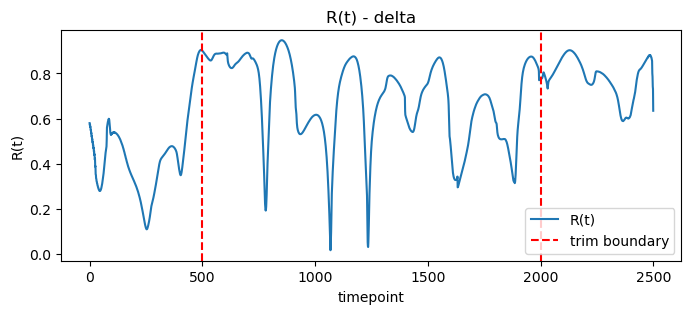

--- gamma (30-45 Hz) ---
Full epoch:    order=0.8467, metastability=0.1813
Trimmed epoch: order=0.8371, metastability=0.1895
Order diff: 0.0096, Metastability diff: 0.0082


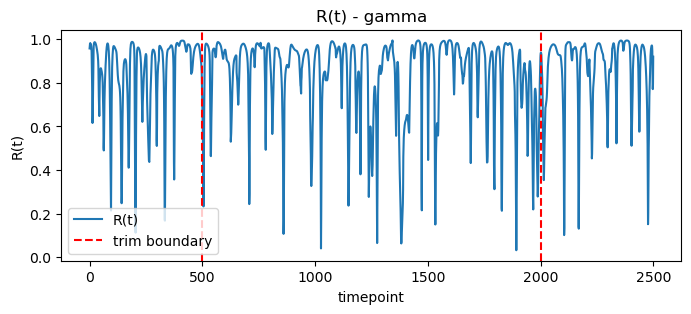

In [25]:
# Run for delta (worst case) and gamma (best case)
R_t_delta, R_t_delta_trimmed = kop_diagnostic(epochs, "delta", *bands["delta"], trim_frac=trim_frac)
R_t_gamma, R_t_gamma_trimmed = kop_diagnostic(epochs, "gamma", *bands["gamma"], trim_frac=trim_frac)

In [26]:
# Extend the diagnostic: check whether the full-vs-trimmed diff is systematic
# (real edge distortion) or scattered (ordinary epoch-to-epoch R(t) variability)
# across all retained epochs for this subject, not just epoch 0.

def kop_diagnostic_all_epochs(epochs, band_name, low, high, trim_frac=0.2):
    epochs_filt = epochs.copy().filter(l_freq=low, h_freq=high, picks=eeg_picks, verbose=False)
    epochs_filt.apply_hilbert(picks=eeg_picks, envelope=False)

    analytic = epochs_filt.get_data(picks=eeg_picks)  # (n_epochs, n_channels, n_times), complex
    theta = np.angle(analytic)

    n_epochs, n_channels, n_times = theta.shape
    trim_n = int(n_times * trim_frac)

    order_diffs = []
    meta_diffs = []

    for ep in range(n_epochs):
        theta_epoch = theta[ep]
        R_t = np.abs(np.mean(np.exp(1j * theta_epoch), axis=0))
        R_t_trimmed = R_t[trim_n: n_times - trim_n]

        order_diffs.append(R_t.mean() - R_t_trimmed.mean())
        meta_diffs.append(R_t.std() - R_t_trimmed.std())

    order_diffs = np.array(order_diffs)
    meta_diffs = np.array(meta_diffs)

    print(f"--- {band_name} ({low}-{high} Hz), n_epochs={n_epochs} ---")
    print(f"Order diff:         mean={order_diffs.mean():.4f}, std={order_diffs.std():.4f}")
    print(f"Metastability diff: mean={meta_diffs.mean():.4f}, std={meta_diffs.std():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].bar(range(n_epochs), order_diffs)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f"{band_name}: order diff per epoch")
    axes[0].set_xlabel("epoch")

    axes[1].bar(range(n_epochs), meta_diffs)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f"{band_name}: metastability diff per epoch")
    axes[1].set_xlabel("epoch")

    plt.tight_layout()
    plt.show()

    return order_diffs, meta_diffs

--- delta (2-4 Hz), n_epochs=23 ---
Order diff:         mean=0.0087, std=0.0273
Metastability diff: mean=0.0026, std=0.0146


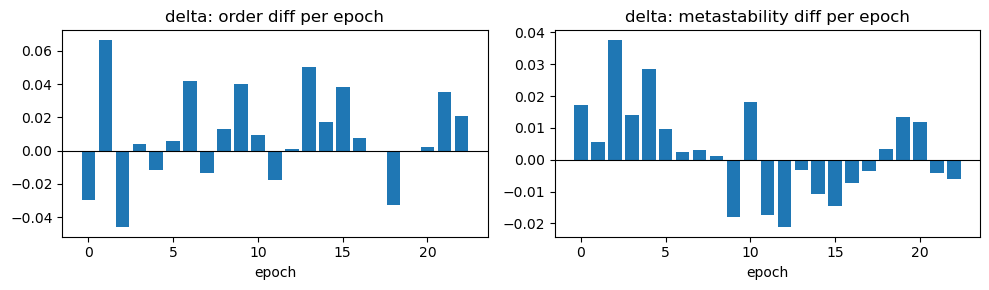

--- gamma (30-45 Hz), n_epochs=23 ---
Order diff:         mean=-0.0003, std=0.0097
Metastability diff: mean=-0.0008, std=0.0082


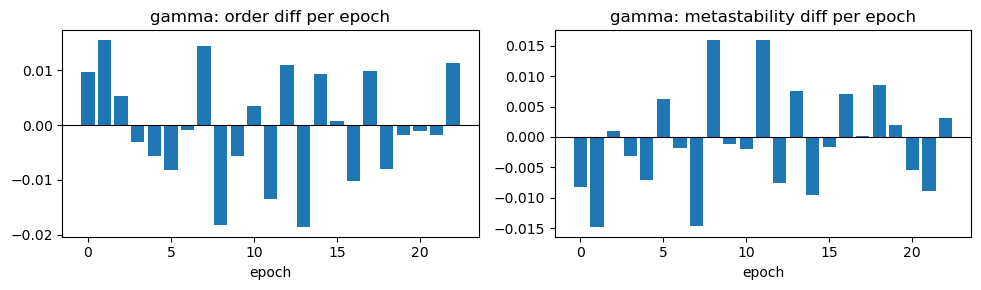

In [27]:
order_diffs_delta, meta_diffs_delta = kop_diagnostic_all_epochs(epochs, "delta", *bands["delta"], trim_frac=trim_frac)
order_diffs_gamma, meta_diffs_gamma = kop_diagnostic_all_epochs(epochs, "gamma", *bands["gamma"], trim_frac=trim_frac)

**Filter edge-effect check (resolved).** Concern: band-pass filtering short (~5s) epochs could distort instantaneous phase near epoch
boundaries, most severely for narrow/low-frequency bands. Checked via full-epoch vs. trimmed-epoch (20% each side) order parameter and
metastability, across all 23 retained epochs, pilot subject, delta (worst case) and gamma (best case). Delta: order diff mean=0.0087 (std=0.0273); gamma: order diff mean=-0.0003 (std=0.0097). In both bands, mean diff is small relative to epoch-to-epoch spread, and diffs alternate in sign rather than trending one direction - consistent with ordinary R(t) variability, not systematic filter distortion. Full
epochs used without trimming.

In [28]:
#Confirm apply_hilbert() returns expected result expect 
# (complex dtype, same shape, applied along the time axis)
epochs_test = epochs.copy().filter(l_freq=8, h_freq=13, picks=eeg_picks, verbose=False)
epochs_test.apply_hilbert(picks=eeg_picks, envelope=False)
data = epochs_test.get_data(picks=eeg_picks)
print(data.dtype)   # expect complex
print(data.shape)   # expect (n_epochs, n_channels, n_times) - same as before filtering

complex128
(23, 26, 2500)


In [29]:
# Run the refactored compute_kuramoto on the pilot subject and validate output

import importlib
import src.features
importlib.reload(src.features)
from src.features import compute_kuramoto

kuramoto_results = compute_kuramoto(epochs, bands)

print(f"Total keys: {len(kuramoto_results)}")  # expect 10 (5 bands x 2 metrics)
for k, v in kuramoto_results.items():
    print(f"{k}: {v:.4f}")

Total keys: 10
delta_order: 0.6654
delta_metastability: 0.1923
theta_order: 0.6559
theta_metastability: 0.1864
alpha_order: 0.5998
alpha_metastability: 0.1983
beta_order: 0.7358
beta_metastability: 0.2146
gamma_order: 0.8705
gamma_metastability: 0.1693


In [30]:
# Cross-check against the diagnostic's already-validated full-epoch numbers
# for delta and gamma (order_diffs_delta etc. came from the same
# filter -> Hilbert -> R(t) pipeline, just not yet wrapped in compute_kuramoto)

print("Delta order (compute_kuramoto):", kuramoto_results["delta_order"])
print("Delta order (diagnostic, epoch 0 full):", 0.6576)  # from earlier diagnostic printout

print("Gamma order (compute_kuramoto):", kuramoto_results["gamma_order"])
print("Gamma order (diagnostic, epoch 0 full):", 0.8467)

Delta order (compute_kuramoto): 0.6654283949422058
Delta order (diagnostic, epoch 0 full): 0.6576
Gamma order (compute_kuramoto): 0.8705152652707209
Gamma order (diagnostic, epoch 0 full): 0.8467


In [31]:
# Manual derivation of Kuramoto order parameter and metastability,
# independent of compute_kuramoto, to give the equality check something
# real to compare against - mirrors the PLI/coherence-PLV pattern.
# Reuses the same filter -> Hilbert -> phase -> R(t) logic as the earlier
# diagnostic, extended to all five bands and the same per-subject
# aggregation (mean across epochs) that compute_kuramoto uses.

kuramoto_results_manual = {}

for band_name, (low, high) in bands.items():
    epochs_filt = epochs.copy().filter(l_freq=low, h_freq=high, picks=eeg_picks, verbose=False)
    epochs_filt.apply_hilbert(picks=eeg_picks, envelope=False)
    analytic = epochs_filt.get_data(picks=eeg_picks)
    theta = np.angle(analytic)

    order_per_epoch = []
    metastability_per_epoch = []
    for ep in range(theta.shape[0]):
        R_t = np.abs(np.mean(np.exp(1j * theta[ep]), axis=0))
        order_per_epoch.append(R_t.mean())
        metastability_per_epoch.append(R_t.std())

    kuramoto_results_manual[f"{band_name}_order"] = np.mean(order_per_epoch)
    kuramoto_results_manual[f"{band_name}_metastability"] = np.mean(metastability_per_epoch)

print(len(kuramoto_results_manual))  # expect 10

10


In [32]:
# Full equality check: manually-derived vs. compute_kuramoto's refactored output

mismatches = {
    k: (kuramoto_results_manual[k], kuramoto_results[k])
    for k in kuramoto_results_manual
    if kuramoto_results_manual[k] != kuramoto_results[k]
}
print(f"Mismatched keys: {len(mismatches)} / {len(kuramoto_results_manual)}")
if mismatches:
    for k, (manual, refactored) in mismatches.items():
        print(f"{k}: manual={manual}, refactored={refactored}")

Mismatched keys: 0 / 10


In [33]:
# Small batch of subjects for the kuramoto function 
import time

start = time.time()
batch_results = []
for subject_id in batch_subject_ids:
    result = extract_subject_features(subject_id, condition, variant, data_dir, qc_log, bands)
    batch_results.append(result)
elapsed = time.time() - start

batch_df = pd.DataFrame(batch_results)
print(batch_df.shape)
print(batch_df['reason'].tolist())
print(f"Time for {len(batch_subject_ids)} subjects: {elapsed:.1f}s -> est. full cohort: {elapsed/len(batch_subject_ids)*160:.1f}s")

kuramoto_cols = [c for c in batch_df.columns if c.endswith('_order') or c.endswith('_metastability')]
print(f"Kuramoto columns: {len(kuramoto_cols)}")  # expect 10

Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88045809/sub-88045809_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLI
    computing cross-spectral density for epoch 1
    computing cross-spectral de

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 12
    computing cross-spectral density for epoch 13
    computing cross-spectral density for epoch 14
    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 21 events (all good), 0 – 4.998 s (baseline off), ~12.5 MiB, data loaded,
 '1': 21>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88022765/sub-88022765_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    

...

    computing cross-spectral density for epoch 13
    computing cross-spectral density for epoch 14
    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
[Connectivity computation done]
Reading /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives_heog_off/sub-88077569/sub-88077569_restEC-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4998.00 ms
        0 CTF compensation matrices available
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Effective window size : 4.096 (s)
Connectivity computation...
  

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:109: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
Connectivity computation...
    using t=0.000s..4.998s for estimation (2500 points)
    computing connectivity for the bands:
     band 1: 2.0Hz..4.0Hz (11 points)
     band 2: 4.0Hz..8.0Hz (21 points)
     band 3: 8.0Hz..13.0Hz (26 points)
     band 4: 13.0Hz..30.0Hz (86 points)
     band 5: 30.0Hz..45.0Hz (76 points)
    connectivity scores will be averaged for each band
    computing connectivity for 325 connections
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence, PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral

/Users/romyweinstock/eeg-rtms-response-prediction/src/features.py:149: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 24 events (all good), 0 – 4.998 s (baseline off), ~14.2 MiB, data loaded,
 '1': 24>, so metadata was not modified.
  con_multi = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
[Connectivity computation done]
(6, 5031)
['ok', 'ok', 'ok', 'ok', 'ok', 'ok']
Time for 6 subjects: 7.7s -> est. full cohort: 204.7s
Kuramoto columns: 10


## Interpretation - Kuramoto order parameter and metastability

Validated on the pilot subject and a 6-subject batch.

**Checklist results:**

- Column count: 10 (5 bands x 2 metrics), exact match
- No NaNs; order parameter bounded [0,1]
- Filter edge-effect check (delta worst case, gamma best case, all 23 epochs): diffs small and alternating, not systematic - no trimming   applied
- Refactor validation: manual derivation vs. refactored output, 0/10 mismatches
- Batch check (6 subjects): 6/6 succeeded, all 5031 columns present, values within bounds, no NaNs

**Orchestrator.** Updated to call `compute_kuramoto` alongside the other
three functions. Batch: 6/6 succeeded. Runtime ~3.4 min estimated for
full cohort.

**Progress:**

- [x] Band power
- [x] PLI
- [x] Coherence, PLV
- [x] Kuramoto